<a href="https://www.kaggle.com/code/pranamshah/notebook30e100700a?scriptVersionId=297867969" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

2026-02-15 14:40:50.257978: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771166450.529188      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771166450.609898      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771166451.297457      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771166451.297526      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771166451.297529      17 computation_placer.cc:177] computation placer alr

Epoch 1/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 210ms/step - accuracy: 0.7339 - loss: 0.4617 - val_accuracy: 0.9882 - val_loss: 0.1398
Epoch 2/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step - accuracy: 0.9978 - loss: 0.0308 - val_accuracy: 0.9882 - val_loss: 0.1211
Epoch 3/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 191ms/step - accuracy: 0.9941 - loss: 0.0524 - val_accuracy: 0.9882 - val_loss: 0.0595
Epoch 4/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step - accuracy: 0.9957 - loss: 0.0236 - val_accuracy: 0.9882 - val_loss: 0.0642
Epoch 5/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 193ms/step - accuracy: 0.9979 - loss: 0.0126 - val_accuracy: 0.9882 - val_loss: 0.0599
Epoch 6/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 187ms/step - accuracy: 0.9979 - loss: 0.0136 - val_accuracy: 0.9882 - val_loss: 0.0600
Epoch 7/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step - accuracy: 0.9978 - loss: 0.0140 - val_accuracy: 0.9882 - val_loss: 0.0583
Epoch 8/15
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 194ms/step - accuracy: 0.9983 - loss: 0.0112 - val_accuracy: 0.

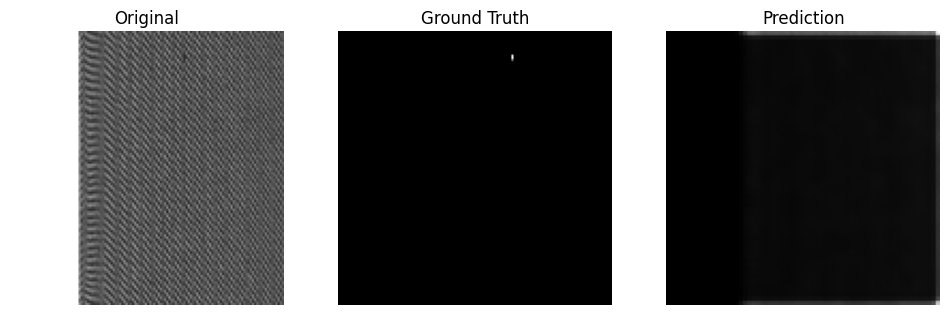

IoU: 0.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Result: DEFECT DETECTED
Defect %: 9.155


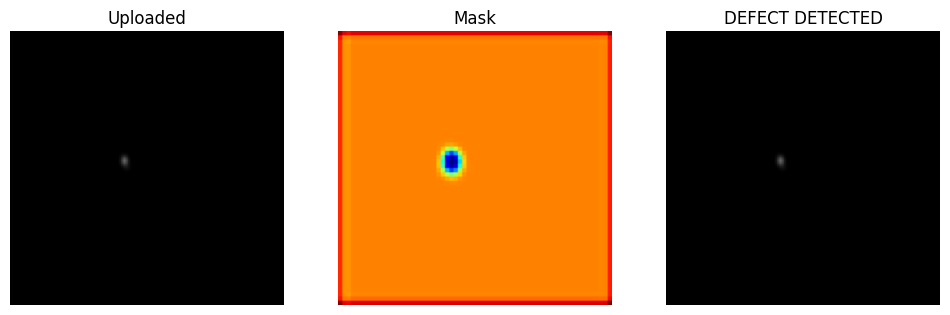

In [1]:
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers,models

BASE_PATH="/kaggle/input/aitex-fabric-image-database"
IMAGE_PATH=os.path.join(BASE_PATH,"Defect_images")
MASK_PATH=os.path.join(BASE_PATH,"Mask_images")
IMG_SIZE=128

def load_data(img_path,mask_path):
    images=[]
    masks=[]
    for file in os.listdir(img_path):
        img_file=os.path.join(img_path,file)
        mask_name=file.replace(".png","_mask.png")
        mask_file=os.path.join(mask_path,mask_name)
        if not os.path.exists(mask_file):
            continue
        img=cv2.imread(img_file)
        img=cv2.resize(img,(IMG_SIZE,IMG_SIZE))
        img=img/255.0
        mask=cv2.imread(mask_file,0)
        mask=cv2.resize(mask,(IMG_SIZE,IMG_SIZE))
        mask=mask/255.0
        mask=np.expand_dims(mask,axis=-1)
        images.append(img)
        masks.append(mask)
    return np.array(images),np.array(masks)

X,Y=load_data(IMAGE_PATH,MASK_PATH)
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

def unet():
    inputs=layers.Input((128,128,3))
    c1=layers.Conv2D(32,3,activation='relu',padding='same')(inputs)
    c1=layers.Conv2D(32,3,activation='relu',padding='same')(c1)
    p1=layers.MaxPooling2D()(c1)
    c2=layers.Conv2D(64,3,activation='relu',padding='same')(p1)
    c2=layers.Conv2D(64,3,activation='relu',padding='same')(c2)
    u1=layers.UpSampling2D()(c2)
    concat=layers.concatenate([u1,c1])
    outputs=layers.Conv2D(1,1,activation='sigmoid')(concat)
    return models.Model(inputs,outputs)

model=unet()
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.fit(X_train,Y_train,validation_data=(X_test,Y_test),epochs=15,batch_size=4)

pred=model.predict(X_test[:1])
plt.figure(figsize=(12,4))
plt.subplot(1,3,1);plt.imshow(X_test[0]);plt.title("Original");plt.axis("off")
plt.subplot(1,3,2);plt.imshow(Y_test[0].squeeze(),cmap='gray');plt.title("Ground Truth");plt.axis("off")
plt.subplot(1,3,3);plt.imshow(pred[0].squeeze(),cmap='gray');plt.title("Prediction");plt.axis("off")
plt.show()

def iou(y_true,y_pred):
    y_pred=y_pred>0.3
    inter=np.logical_and(y_true,y_pred)
    union=np.logical_or(y_true,y_pred)
    return np.sum(inter)/np.sum(union)

print("IoU:",iou(Y_test[0],pred[0]))

NEW_IMAGE_PATH="/kaggle/input/datasets/pranamshah/fabric/fabric.jpg"
new_img=cv2.imread(NEW_IMAGE_PATH)
new_img=cv2.resize(new_img,(128,128))
new_img=cv2.GaussianBlur(new_img,(5,5),0)
new_img_norm=new_img/255.0

prediction=model.predict(np.expand_dims(new_img_norm,axis=0))
pred_mask=prediction[0]
defect_ratio=np.sum(pred_mask>0.3)/pred_mask.size

if defect_ratio>0.001:
    result="DEFECT DETECTED"
else:
    result="NO DEFECT DETECTED"

print("Result:",result)
print("Defect %:",round(defect_ratio*100,3))

plt.figure(figsize=(12,4))
plt.subplot(1,3,1);plt.imshow(cv2.cvtColor(new_img,cv2.COLOR_BGR2RGB));plt.title("Uploaded");plt.axis("off")
plt.subplot(1,3,2);plt.imshow(pred_mask.squeeze(),cmap='jet');plt.title("Mask");plt.axis("off")
plt.subplot(1,3,3);plt.imshow(cv2.cvtColor(new_img,cv2.COLOR_BGR2RGB));plt.title(result);plt.axis("off")
plt.show()